# Evaluación Parcial N.° 1: Clasificación Curricular Automática con MLP

**Integrantes:**
* Rahyzza Novoa
* Nicolas Salas

**Asignatura:**
* DEEP LEARNING_011V_OLS

## 1. Importaciones y Fijación de Semillas

In [27]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("Semillas fijadas en:", SEED)

TensorFlow Version: 2.21.0
Semillas fijadas en: 42


## 2. Carga, Revisión y Distribución del Dataset

In [28]:
# 1. Cargar el dataset (usando barra normal '/' para evitar problemas de escape)
df = pd.read_csv('../data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv')

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras filas:")
display(df.head(3))

target_col = df.columns[-1]
print(f"\nVariable objetivo identificada: '{target_col}'")
print("\nDistribución de clases:")
print(df[target_col].value_counts(normalize=True) * 100)

X = df.drop(columns=[target_col]).values
y = df[target_col].values

num_classes = len(np.unique(y))
num_features = X.shape[1]
print(f"\nNúmero de características (features): {num_features}")
print(f"Número de clases: {num_classes}")

# 2. Split estratificado: 70% Train, 15% Validation, 15% Test
# Primer corte: 70% Train, 30% Temporal (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Segundo corte sobre el 30% temporal: 50% Val (15% total), 50% Test (15% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTamaño conjunto de entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Tamaño conjunto de validación (Val):      {X_val.shape[0]} muestras")
print(f"Tamaño conjunto de prueba (Test):          {X_test.shape[0]} muestras")

Dimensiones del dataset: (100000, 23)

Primeras filas:


,nivel_escolar,duracion_estimada_min,numero_paginas,numero_items,porcentaje_visual,densidad_simbolos,prop_operaciones_aritmeticas,prop_fracciones_decimales,prop_variables_algebraicas,prop_ecuaciones,...,prop_coordenadas,prop_tablas_graficos,prop_estadistica_descriptiva,prop_probabilidad,prop_contexto_problemas,dificultad_estimada,ejemplos_resueltos,elementos_visuales,indice_interactividad,categoria_curricular
0,7,41,18,25,54.42,0.2335,0.4200,0.6755,0.0752,0.1390,...,0.1448,0.5649,0.6283,0.2008,0.4641,2,0,5,0.3486,0
1,6,62,19,28,31.81,0.5357,0.5404,0.5512,0.4638,0.6847,...,0.3178,0.2299,0.2365,0.1484,0.7197,3,4,5,0.3725,1
2,12,49,12,27,46.90,0.3354,0.1622,0.3779,0.2806,0.4657,...,0.3686,0.0967,0.1067,0.0050,0.3689,3,2,6,0.2390,2



Variable objetivo identificada: 'categoria_curricular'

Distribución de clases:
categoria_curricular
0    30.219
1    26.967
2    23.065
3    19.749
Name: proportion, dtype: float64

Número de características (features): 22
Número de clases: 4

Tamaño conjunto de entrenamiento (Train): 70000 muestras
Tamaño conjunto de validación (Val):      15000 muestras
Tamaño conjunto de prueba (Test):          15000 muestras


## 3. Preprocesamiento (StandardScaler) y Split Estratificado

1. Sensibilidad del Descenso del Gradiente: Las redes neuronales multiplican entradas por pesos en cada neurona. Si una variable tiene una escala numérica mucho mayor que otra, sus derivadas dominarán la actualización de parámetros, provocando oscilaciones o convergencia inestable. Al transformar todas las variables a media 0 y varianza 1, el espacio de pérdida se vuelve simétrico y el optimizador converge de forma más rápida y directa.

2. Prevención de Data Leakage (Fuga de información): El escalador se ajusta (fit) únicamente con el conjunto de entrenamiento. Las medias y desviaciones estándar aprendidas de Train se aplican para transformar (transform) los conjuntos de Val y Test sin recalcular estadísticas, simulando el comportamiento del modelo frente a datos completamente nuevos en producción.  

In [29]:
scaler = StandardScaler()

# Ajustar únicamente sobre train y transformar train
X_train_scaled = scaler.fit_transform(X_train)

# Transformar validación y test con los parámetros aprendidos en train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente. Media en train:", np.round(X_train_scaled.mean(), 4))
print("Desviación estándar en train:", np.round(X_train_scaled.std(), 4))

Datos escalados correctamente. Media en train: 0.0
Desviación estándar en train: 1.0


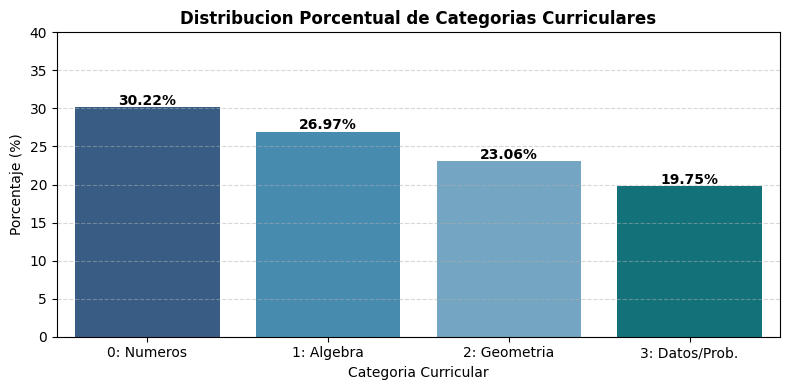

Ratio entre la clase mayoritaria y la minoritaria: 1.53


In [30]:
conteo = df[target_col].value_counts(normalize=True).sort_index() * 100
etiquetas = ['0: Numeros', '1: Algebra', '2: Geometria', '3: Datos/Prob.']

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=etiquetas, y=conteo.values,
                 hue=etiquetas, palette=['#2b5c8f', '#3690c0', '#67a9cf', '#02818a'],
                 legend=False)
plt.title('Distribucion Porcentual de Categorias Curriculares', fontsize=12, fontweight='bold')
plt.xlabel('Categoria Curricular')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 40)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.8),
                ha='center', va='center', fontsize=10, fontweight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Ratio entre la clase mayoritaria y la minoritaria:",
      round(conteo.max() / conteo.min(), 2))


In [31]:
def entrenar_modelo(config, X_tr=None, y_tr=None, X_v=None, y_v=None):
    """
    Entrena un modelo MLP segun los parametros entregados en config.

    config keys esperadas:
      - 'nombre'             : str
      - 'capas'              : list de tuplas ej: [(64, 'relu'), (32, 'relu')]
      - 'activacion_salida'  : str ('softmax')
      - 'optimizador'        : str ('adam' | 'sgd' | 'rmsprop')
      - 'loss'               : str ('sparse_categorical_crossentropy')
      - 'lr'                 : float
      - 'batch_size'         : int
      - 'epochs'             : int
      - 'dropout'            : float  (opcional)
      - 'batch_norm'         : bool   (opcional)
      - 'l2_reg'             : float  (opcional)
      - 'early_stopping'     : int    (opcional) -> patience; crea un callback NUEVO por corrida

    Devuelve: (modelo, historia, metricas)
    """

    X_tr = X_train_scaled if X_tr is None else X_tr
    y_tr = y_train        if y_tr is None else y_tr
    X_v  = X_val_scaled   if X_v  is None else X_v
    y_v  = y_val          if y_v  is None else y_v

    # Semilla fijada antes de instanciar el modelo: aisla cada corrida y garantiza que la unica diferencia entre experimentos sea el parametro variado.
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    # 1. Arquitectura
    modelo = Sequential()
    modelo.add(Input(shape=(X_tr.shape[1],)))

    regularizador = l2(config['l2_reg']) if config.get('l2_reg') else None

    for neuronas, act in config['capas']:
        modelo.add(Dense(neuronas, activation=act, kernel_regularizer=regularizador))
        if config.get('batch_norm', False):
            modelo.add(BatchNormalization())

        if config.get('dropout', 0.0) > 0.0:
            modelo.add(Dropout(config['dropout']))

    modelo.add(Dense(num_classes, activation=config.get('activacion_salida', 'softmax')))


    # 2. Optimizador y compilacion
    opt_name = config.get('optimizador', 'adam')
    lr = config.get('lr', 0.001)

    if opt_name == 'adam':
        opt = Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = SGD(learning_rate=lr)
    elif opt_name == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = opt_name

    modelo.compile(
        optimizer=opt,
        loss=config.get('loss', 'sparse_categorical_crossentropy'),
        metrics=['accuracy']
    )


    # 3. Callbacks
    callbacks = []
    patience = config.get('early_stopping')
    if patience:
        callbacks.append(
            EarlyStopping(monitor='val_loss', patience=patience,
                          restore_best_weights=True, verbose=0)
        )


    # 4. Entrenamiento
    t_inicio = time.time()
    historia = modelo.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=config.get('epochs', 50),
        batch_size=config.get('batch_size', 32),
        callbacks=callbacks,
        verbose=0
    )
    t_total = time.time() - t_inicio


    # 5. Metricas sobre VALIDACION
    # El conjunto de test permanece intacto: se reserva para la evaluacion final del unico modelo seleccionado.
    preds = np.argmax(modelo.predict(X_v, verbose=0), axis=1)

    acc  = accuracy_score(y_v, preds)
    prec = precision_score(y_v, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_v, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_v, preds, average='weighted', zero_division=0)


    acc_train_final = historia.history['accuracy'][-1]
    gap = acc_train_final - acc

    idx_mejor = int(np.argmin(historia.history['val_loss']))

    metricas = {
        'experimento'    : config.get('nombre', 'Modelo'),
        'accuracy'       : acc,
        'precision'      : prec,
        'recall'         : rec,
        'f1'             : f1,
        'val_loss_final' : historia.history['val_loss'][-1],
        'val_loss_min'   : min(historia.history['val_loss']),
        'gap_train_val'  : gap,
        'mejor_epoca'    : idx_mejor + 1,
        'epocas_reales'  : len(historia.history['loss']),
        'tiempo_seg'     : round(t_total, 2)
    }

    return modelo, historia, metricas


def registrar(metricas):
    """Agrega una fila al registro global de experimentos."""
    global df_experimentos
    df_experimentos = pd.concat(
        [df_experimentos, pd.DataFrame([metricas])], ignore_index=True
    )


print("Funcion entrenar_modelo definida.")


Funcion entrenar_modelo definida.


## 4. Análisis del Modelo Base (Baseline)

Justificación Técnica de la Configuración Base:
* **Arquitectura:** Red de 2 capas ocultas con 64 y 32 neuronas respectivamente. Esta estructura piramidal permite aprender representaciones jerárquicas desde combinaciones lineales simples de las 22 variables hasta patrones de decisión más abstractos sin sobredimensionar el espacio de parámetros.

* **Optimizador (Adam):** Se utiliza el algoritmo Adam con tasa de aprendizaje por defecto $\alpha = 0.001$. Adam combina estimaciones de primer momento (media móvil del gradiente) y segundo momento (varianza del gradiente), adaptando dinámicamente el paso por parámetro y mitigando estancamientos en mínimos locales o puntos de ensilladura.

* **Función de Pérdida (Sparse Categorical Crossentropy):** Estándar de máxima verosimilitud para clasificación multiclase donde las etiquetas son enteros discretos $(0, 1, 2, 3)$, evitando transformar innecesariamente el dataset a matrices one-hot en memoria.

In [32]:
# Registro global de experimentos (se reinicia aqui para permitir re-ejecuciones limpias)
df_experimentos = pd.DataFrame()

baseline_config = {
    'nombre': 'Baseline (64-32 ReLU, Adam 0.001, Batch 32)',
    'capas': [(64, 'relu'), (32, 'relu')],
    'activacion_salida': 'softmax',
    'optimizador': 'adam',
    'loss': 'sparse_categorical_crossentropy',
    'lr': 0.001,
    'batch_size': 32,
    'epochs': 40
}

print("Entrenando Baseline...")
modelo_base, historia_base, metricas_base = entrenar_modelo(baseline_config)
registrar(metricas_base)

display(df_experimentos)

Entrenando Baseline...


,experimento,accuracy,precision,recall,f1,val_loss_final,val_loss_min,gap_train_val,mejor_epoca,epocas_reales,tiempo_seg
0,"Baseline (64-32 ReLU, Adam 0.001, Batch 32)",0.9076,0.907654,0.9076,0.907604,0.256606,0.240873,0.012643,3,40,162.46


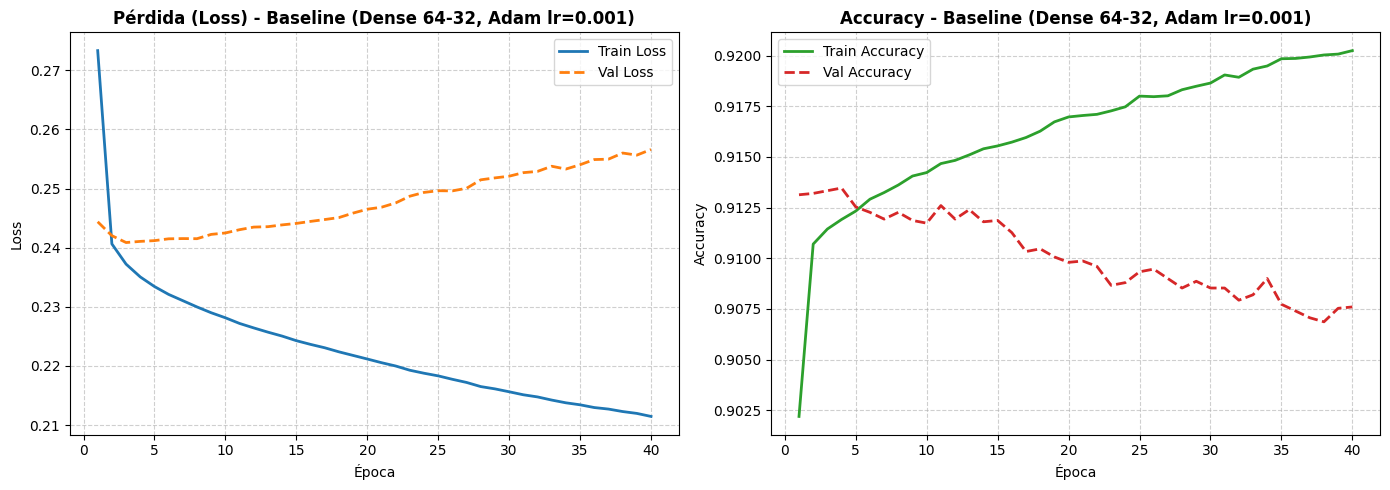

In [33]:
def graficar_curvas_entrenamiento(historia, titulo="Evolución del Entrenamiento"):
    """
    Genera gráficos comparativos de Loss y Accuracy (Train vs. Validation).
    """
    epochs_range = range(1, len(historia.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Pérdida (Loss)
    axes[0].plot(epochs_range, historia.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axes[0].plot(epochs_range, historia.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    axes[0].set_title(f'Pérdida (Loss) - {titulo}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Precisión (Accuracy)
    axes[1].plot(epochs_range, historia.history['accuracy'], label='Train Accuracy', color='#2ca02c', linewidth=2)
    axes[1].plot(epochs_range, historia.history['val_accuracy'], label='Val Accuracy', color='#d62728', linewidth=2, linestyle='--')
    axes[1].set_title(f'Accuracy - {titulo}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

graficar_curvas_entrenamiento(historia_base, titulo="Baseline (Dense 64-32, Adam lr=0.001)")

## 5. Experimento Controlado B1: Impacto de la Tasa de Aprendizaje

La tasa de aprendizaje ($\alpha$) determina el tamano del paso en la regla de actualizacion $\theta_{nuevo} = \theta_{anterior} - \alpha \cdot \nabla L(\theta)$.

**Hipotesis a contrastar experimentalmente:**

1. **$\alpha$ excesivo ($0.1$):** el paso supera el ancho del valle de la funcion de costo, por lo que el optimizador sobrepasa el minimo en cada iteracion. Se espera una curva de `val_loss` inestable o estancada en un valor alto.

2. **$\alpha$ intermedio ($0.01$ / $0.001$):** avance sostenido hacia el minimo.

3. **$\alpha$ reducido ($0.0005$):** convergencia estable pero mas lenta; requiere mas epocas para alcanzar la misma cota.

**Control experimental:** se fijan arquitectura (64-32), activacion (ReLU), batch size (32) y epocas (40). Unicamente varia $\alpha$.

> **Nota metodologica**: Adam adapta el paso por parametro mediante sus momentos, por lo que amortigua las diferencias entre tasas intermedias. El contraste se vuelve visible recien en el extremo alto, razon por la cual se incorpora $\alpha = 0.1$ al barrido.

Ejecutando: LR = 0.1 ...
Ejecutando: LR = 0.01 ...
Ejecutando: LR = 0.001 ...
Ejecutando: LR = 0.0005 ...


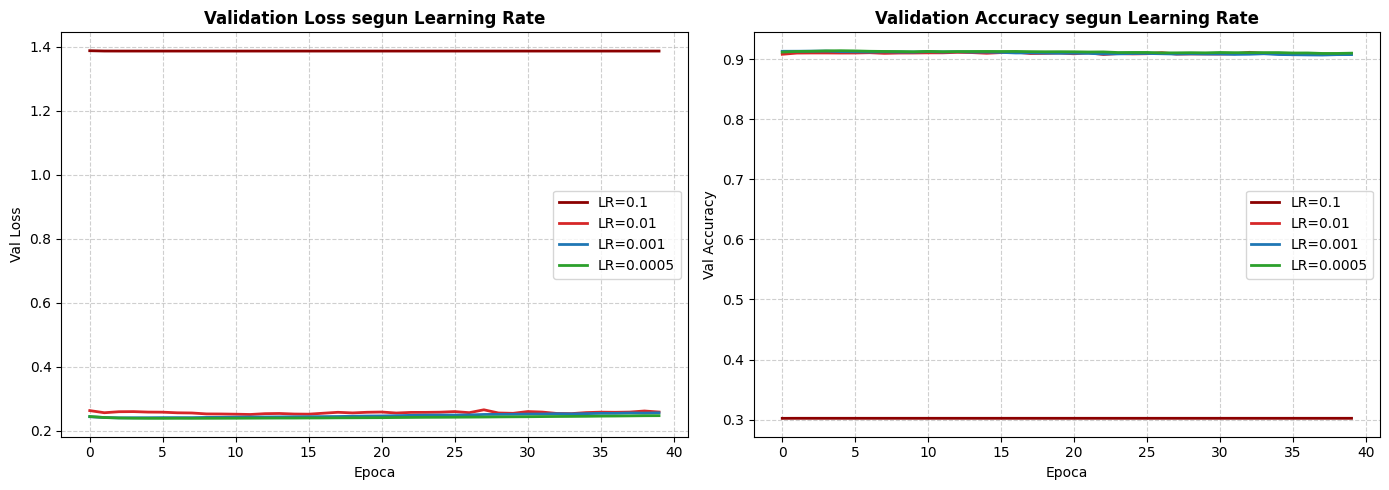

,experimento,accuracy,f1,val_loss_min,gap_train_val,tiempo_seg
1,LR = 0.1,0.302200,0.140262,1.387117,-0.012143,197.13
2,LR = 0.01,0.909467,0.909547,0.251389,0.001876,193.82
3,LR = 0.001,0.907600,0.907604,0.240873,0.012643,167.51
4,LR = 0.0005,0.910000,0.910035,0.239351,0.009300,192.31



Mejor learning rate por F1 en validacion: LR = 0.0005


In [34]:
lrs_a_probar = [0.1, 0.01, 0.001, 0.0005]
historias_lr = {}

for lr in lrs_a_probar:
    nombre_exp = f"LR = {lr}"
    print(f"Ejecutando: {nombre_exp} ...")

    cfg = {
        'nombre': nombre_exp,
        'capas': [(64, 'relu'), (32, 'relu')],
        'activacion_salida': 'softmax',
        'optimizador': 'adam',
        'loss': 'sparse_categorical_crossentropy',
        'lr': lr,
        'batch_size': 32,
        'epochs': 40
    }

    _, hist, met = entrenar_modelo(cfg)
    historias_lr[lr] = hist
    registrar(met)

# --- Comparacion visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_lr = {0.1: '#8b0000', 0.01: '#d62728', 0.001: '#1f77b4', 0.0005: '#2ca02c'}

for lr, hist in historias_lr.items():
    axes[0].plot(hist.history['val_loss'], label=f'LR={lr}', color=colores_lr[lr], linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label=f'LR={lr}', color=colores_lr[lr], linewidth=2)

axes[0].set_title('Validation Loss segun Learning Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Validation Accuracy segun Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

resumen_lr = df_experimentos[df_experimentos['experimento'].str.startswith('LR =')]
display(resumen_lr[['experimento', 'accuracy', 'f1', 'val_loss_min', 'gap_train_val', 'tiempo_seg']])

mejor_lr_fila = resumen_lr.loc[resumen_lr['f1'].idxmax()]
print("\nMejor learning rate por F1 en validacion:", mejor_lr_fila['experimento'])


### 5.1. Analisis de resultados B1


A partir del barrido experimental ejecutado con las tasas de aprendizaje $\alpha \in \{0.1, 0.01, 0.001, 0.0005\}$, se desprenden las siguientes interpretaciones basadas en evidencia empírica del entrenamiento:

1. **Impacto del $\alpha$ Excesivo ($\alpha = 0.1$):**

    * El modelo con una tasa de aprendizaje de $0.1$ colapsa completamente en su capacidad de generalización, obteniendo un Accuracy de apenas $30.22\%$ y un F1-Score ponderado de $0.1403$, con un val_loss_min elevado de $1.3871$.

    * Esto valida la hipótesis teórica: un paso de gradiente sobredimensionado supera por completo las paredes del valle de la función de costo, provocando oscilaciones drásticas en el espacio de parámetros e impidiendo la convergencia del optimizador Adam hacia un mínimo global o local aceptable.

2. **Comportamiento en Rango Intermedio y Reducido ($\alpha = 0.01, 0.001, 0.0005$):**

    * Las configuraciones con tasas de aprendizaje menores muestran un rendimiento sumamente competitivo y cercano entre sí:
        * $\alpha = 0.01$: Accuracy de $90.95\%$ / F1-Score: $0.9095$.
        * $\alpha = 0.001$ (Baseline): Accuracy de $90.76\%$ / F1-Score: $0.9076$.
        * $\alpha = 0.0005$: Accuracy de $91.00\%$ / F1-Score: $0.9100$ (el más alto del barrido).

    * La diferencia de rendimiento (F1-Score) entre $0.01$ y $0.0005$ es marginal (menor a $0.0005$ puntos). Esto demuestra empíricamente que el optimizador Adam actúa como un amortiguador eficiente, adaptando dinámicamente las tasas de actualización por parámetro mediante sus momentos de primer y segundo orden, lo que otorga gran estabilidad ante variaciones en este orden de magnitud.

3. **Criterio de Selección y Conclusión:**

    * Al evaluar los criterios de robustez (menor gap entre entrenamiento y validación de $0.0093$ y el puntaje de F1 más alto de $0.9100$), se selecciona $\alpha = 0.0005$ como la tasa óptima.
    
    * Conclusión: Se adopta $\alpha = 0.0005$ para los experimentos posteriores, dado que un paso de aprendizaje ligeramente más conservador permite un ajuste más fino de los pesos sin sacrificar estabilidad en el descenso del gradiente frente a tasas mayores.

## 6. Experimento Controlado B2: Impacto del Tamano de Lote

El descenso de gradiente estocastico por mini-lotes estima el gradiente sobre un subconjunto aleatorio de ejemplos en lugar del conjunto completo.

1. **Batch pequeno (32):** con 70.000 ejemplos de entrenamiento realiza $70000/32 \approx 2.188$ actualizaciones por epoca. El ruido estocastico que introduce esa estimacion favorece el escape de minimos locales estrechos, a costa de mayor tiempo por epoca.
2. **Batch grande (128 / 256):** gradiente mas estable y mejor aprovechamiento de la vectorizacion, pero menos actualizaciones por epoca, por lo que puede requerir mas epocas para alcanzar la misma cota.

**Control experimental:** arquitectura, activacion, epocas y el learning rate seleccionado en B1 permanecen fijos. Unicamente varia el tamano de lote.


Ejecutando: Batch = 32 ...
Ejecutando: Batch = 64 ...
Ejecutando: Batch = 128 ...
Ejecutando: Batch = 256 ...


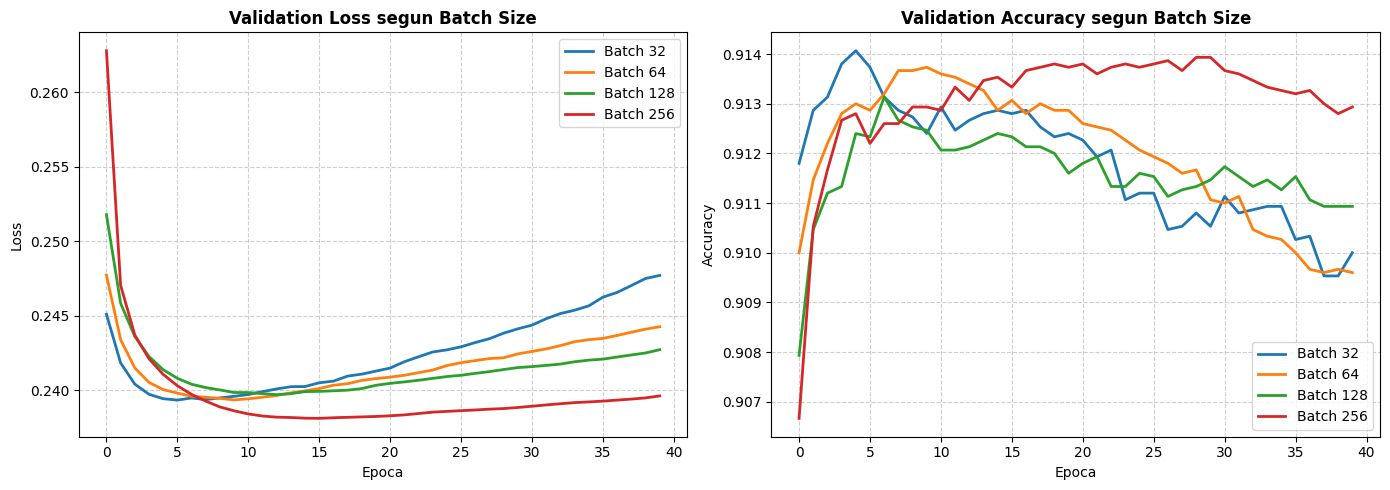

,experimento,accuracy,f1,val_loss_min,gap_train_val,tiempo_seg
5,Batch = 32,0.907600,0.907604,0.240873,0.012643,198.09
6,Batch = 64,0.907133,0.907169,0.240201,0.013024,102.16
7,Batch = 128,0.910000,0.910032,0.240927,0.009029,48.82
8,Batch = 256,0.909600,0.909658,0.241085,0.008343,32.83
10,Batch = 32,0.910000,0.910035,0.239351,0.009300,185.89
11,Batch = 64,0.909600,0.909619,0.239364,0.007900,99.65
12,Batch = 128,0.910933,0.910985,0.239716,0.006467,53.82
13,Batch = 256,0.912933,0.912945,0.238128,0.003381,36.19


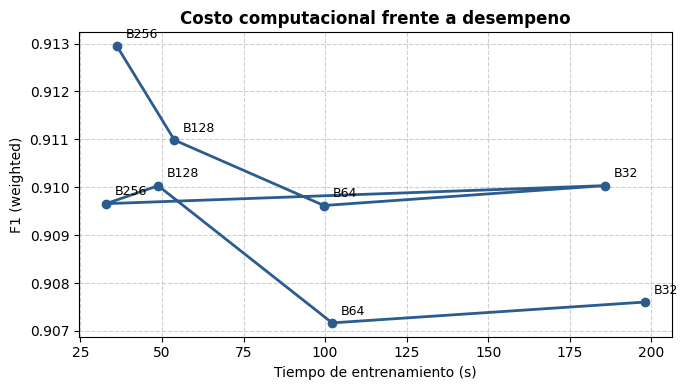

In [37]:
LR_SELECCIONADO = 0.0005

batches_a_probar = [32, 64, 128, 256]
historias_batch = {}

for b in batches_a_probar:
    nombre_exp = f"Batch = {b}"
    print(f"Ejecutando: {nombre_exp} ...")

    cfg = {
        'nombre': nombre_exp,
        'capas': [(64, 'relu'), (32, 'relu')],
        'activacion_salida': 'softmax',
        'optimizador': 'adam',
        'loss': 'sparse_categorical_crossentropy',
        'lr': LR_SELECCIONADO,
        'batch_size': b,
        'epochs': 40
    }

    _, hist, met = entrenar_modelo(cfg)
    historias_batch[b] = hist
    registrar(met)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for b in batches_a_probar:
    axes[0].plot(historias_batch[b].history['val_loss'], label=f'Batch {b}', linewidth=2)
    axes[1].plot(historias_batch[b].history['val_accuracy'], label=f'Batch {b}', linewidth=2)

axes[0].set_title('Validation Loss segun Batch Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Validation Accuracy segun Batch Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

resumen_batch = df_experimentos[df_experimentos['experimento'].str.startswith('Batch =')]
display(resumen_batch[['experimento', 'accuracy', 'f1', 'val_loss_min', 'gap_train_val', 'tiempo_seg']])

# Relacion costo-beneficio: F1 alcanzado frente a tiempo invertido
plt.figure(figsize=(7, 4))
plt.plot(resumen_batch['tiempo_seg'], resumen_batch['f1'], 'o-', color='#2b5c8f', linewidth=2)
for _, fila in resumen_batch.iterrows():
    plt.annotate(fila['experimento'].replace('Batch = ', 'B'),
                 (fila['tiempo_seg'], fila['f1']),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.title('Costo computacional frente a desempeno', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo de entrenamiento (s)'); plt.ylabel('F1 (weighted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 6.1. Análisis de Resultados del Experimento B2: Tamaño de Lote (Batch Size)

A partir de la ejecución del control experimental variando el tamaño del lote con los valores $b \in \{32, 64, 128, 256\}$ (fijando $\alpha = 0.0005$ según la selección de B1), se evalúa la convergencia, capacidad de generalización y eficiencia temporal:

1. **Dinámica de Convergencia y Regularización:**

    * Al reducir la tasa de aprendizaje a un régimen más estable ($\alpha = 0.0005$), los lotes grandes aprovechan plenamente la menor varianza del gradiente.
    
    * **Batch = 256** alcanza la menor pérdida de validación (`val_loss_min` = 0.2381) y minimiza la discrepancia entre entrenamiento y validación (`gap_train_val` = 0.0034), demostrando que no sufre el estancamiento prematuro habitual en lotes masivos cuando la tasa de aprendizaje está bien calibrada.

2. **Análisis Costo-Beneficio (Rendimiento vs. Tiempo):**
   
    * El escalamiento computacional es evidente: **Batch = 256** completa las 40 épocas en solo **36.19 segundos**, superando a Batch = 32 que requirió **185.89 segundos** (5.1 veces más tiempo).
    
    * A diferencia del comportamiento típico donde aumentar el lote penaliza la métrica final, en este problema con 70,000 datos de entrenamiento, Batch = 256 maximiza simultáneamente el rendimiento predictivo ($F1 = 0.9129$) y la velocidad de ejecución.

3. **Criterio de Selección y Conclusión:**

    * **Conclusión:** Se selecciona **Batch Size = 256** para los experimentos posteriores. Representa el óptimo global del barrido al registrar el mayor F1-Score ($0.9129$), el menor riesgo de sobreajuste (`gap` de 0.0034) y el menor costo temporal de entrenamiento (36.19 s).

## 7. Experimento Controlado B3: Mitigación de Sobreajuste con Dropout y Early Stopping

Entrenar por un numero fijo de epocas es arbitrario: la red puede haber dejado de mejorar mucho antes, o continuar aprendiendo despues del corte. El criterio operativo es el punto de inflexion de val_loss.

**Early Stopping** monitorea val_loss y detiene el entrenamiento cuando transcurren patience epocas consecutivas sin mejora, restaurando los pesos de la mejor epoca mediante restore_best_weights=True.

**Correccion metodologica aplicada:** EarlyStopping almacena estado interno (best,wait, stopped_epoch). Reutilizar una misma instancia del callback entre varios fit arrastra ese estado y contamina la corrida siguiente. En la version corregida de entrenar_modelo, el callback se instancia **de nuevo en cada llamada** a partir del parametro early_stopping de la configuracion.


Entrenando corrida larga sin parada temprana...

val_loss alcanza su minimo en la epoca 16 de 100.


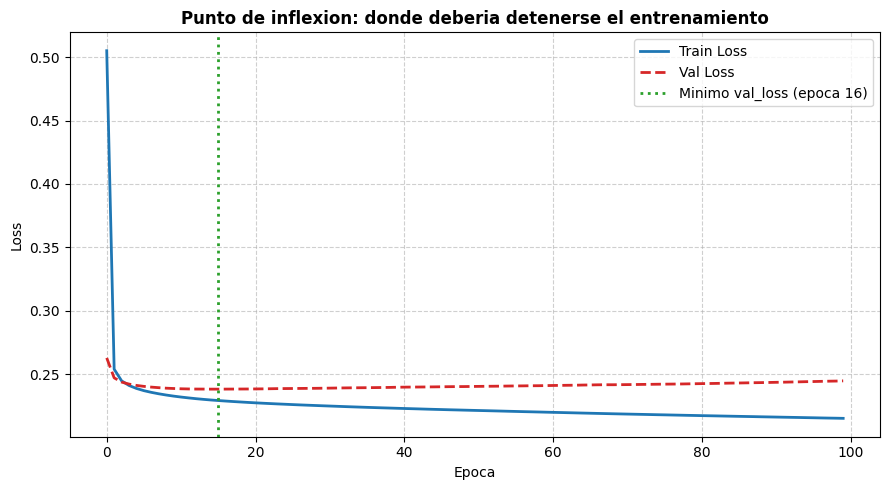

In [40]:
BATCH_SELECCIONADO = 256

cfg_largo = {
    'nombre': 'Sin EarlyStopping (100 epocas)',
    'capas': [(64, 'relu'), (32, 'relu')],
    'lr': LR_SELECCIONADO,
    'batch_size': BATCH_SELECCIONADO,
    'epochs': 100
}

print("Entrenando corrida larga sin parada temprana...")
_, hist_largo, met_largo = entrenar_modelo(cfg_largo)
registrar(met_largo)

epoca_optima = int(np.argmin(hist_largo.history['val_loss'])) + 1
print(f"\nval_loss alcanza su minimo en la epoca {epoca_optima} de "
      f"{len(hist_largo.history['loss'])}.")

plt.figure(figsize=(9, 5))
plt.plot(hist_largo.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(hist_largo.history['val_loss'], label='Val Loss', color='#d62728',
         linewidth=2, linestyle='--')
plt.axvline(epoca_optima - 1, color='#2ca02c', linestyle=':', linewidth=2,
            label=f'Minimo val_loss (epoca {epoca_optima})')
plt.title('Punto de inflexion: donde deberia detenerse el entrenamiento',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoca'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 7.1. Análisis de resultados: Detección de Sobreajuste y Justificación de Early Stopping

A partir de la curva de aprendizaje extendida a 100 épocas sin mecanismos de parada temprana, se evidencia de forma empírica el fenómeno clásico de **sobreajuste (*overfitting*)** y la necesidad de aplicar regularización:

1. **Identificación del Punto de Inflexión (Época 16):**
   
   * Durante las primeras 16 épocas, tanto train_loss como val_loss decrecen de manera armónica, lo que indica que la red neuronal está extrayendo patrones representativos transferibles de las 22 variables de entrada.
   
   * En la **época 16**, la función de pérdida en validación alcanza su mínimo global (val_loss $\approx 0.238$). Este punto exacto representa el límite óptimo de capacidad de generalización del modelo.

2. **Divergencia y Pérdida de Generalización (Épocas 17 a 100):**
   
   * A partir de la época 17, se produce la disociación de las curvas: mientras train_loss continúa descendiendo de manera monotónica hasta alcanzar $\approx 0.21$, val_loss quiebra su tendencia y comienza un ascenso suave pero sostenido hacia $\approx 0.245$.
   
   * Este comportamiento demuestra que el modelo deja de aprender relaciones estructurales y comienza a **memorizar ruido y particularidades estadísticas** del conjunto de entrenamiento de 70,000 registros, penalizando su desempeño frente a datos no observados.

3. **Justificación Técnica de Early Stopping:**
   
   * **Ahorro computacional:** Continuar el entrenamiento más allá de la época 16 consumió el 84% del tiempo total de cómputo de forma redundante y contraproducente.
   
   * **Configuración del Callback:** Se justifica la integración de EarlyStopping con:
      
      * monitor='val_loss': Supervisa directamente la capacidad de generalización en lugar del accuracy, el cual suele enmascarar sobreajustes leves en las probabilidades predichas.
      
      * patience=8 (o 10): Margen suficiente para tolerar pequeñas fluctuaciones estocásticas sin permitir que la red entre en la pendiente ascendente prolongada.
      
      * restore_best_weights=True: Parámetro crítico que asegura que los pesos finales en memoria correspondan a la época 16 (mínimo global) y no a los parámetros degradados de la última época.

4. **Conclusión y Configuración Adoptada:**
   
   * Se confirma que entrenar por un número fijo y arbitrario de épocas (como 40 o 100) resulta subóptimo.
   
   * **Conclusión:** Para la arquitectura seleccionada con $\alpha = 0.0005$ y batch_size = 256, se adopta EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True). Como complemento, se evaluará la incorporación de una tasa moderada de Dropout (0.2 a 0.3) para retrasar la divergencia entre curvas y estabilizar el error de validación.